In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

%matplotlib widget

### Hamiltonian and pulse definition

In [2]:
# Define basis states
ket0 = qt.basis(5, 0)
ket1 = qt.basis(5, 1)
ket2 = qt.basis(5, 2)
ket3 = qt.basis(5, 3)

bra0 = ket0.dag()
bra1 = ket1.dag()
bra2 = ket2.dag()
bra3 = ket3.dag()

# Hamiltonian builder
def Hamiltonian(lambda_0, lambda_1, lambda_2, delta, Delta):
    H0 = delta*ket1*bra1 + (2*delta-Delta)*ket2*bra2 + (3*delta-3*Delta)*ket3*bra3
    H1_dag = (lambda_0/2)*(ket1*bra0)
    H1 = (lambda_0/2)*(ket0*bra1)
    H2_dag = (lambda_1/2)*(ket2*bra1)
    H2 = (lambda_1/2)*(ket1*bra2)
    H3_dag = (lambda_2/2)*(ket3*bra2)
    H3 = (lambda_2/2)*(ket2*bra3)
    return H0, H1, H1_dag, H2, H2_dag, H3, H3_dag

# Pulse-level waveform description
def Omega(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                        / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) # normalization part, truncated Gaussian amplitude will be pulse_specs['A]
    return 0

def add_pulse(pulse_train, pulse_name, start, tg, sigma, A):
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A}
    pulse_train['clock'] += tg

## Rabi oscillation 

Here we present a minimal example: simulating sub-system Rabi oscillation of a multilevel ladder. The goal is to find the relative driving strength $\lambda$ of each individual sub-system $\{|0\rangle, |1\rangle\}, \{|1\rangle, |2\rangle\}, \{|2\rangle, |3\rangle\}$

In [3]:
def sim_rabi_osc(gate_model, subspace, lambda_0, lambda_1, lambda_2, amp_sweep):
    Delta = -2*np.pi*0.3071
    
    # The gamma takes into account that sometimes we drive the system non-resonantly. Here we're on resonant.
    gamma = 0
    
    if subspace == '01':
        delta = -gamma*Delta 
        idx_state = 1
        psi0 = ket0
        tg = 60
    elif subspace == '12':
        delta = Delta - gamma*Delta
        idx_state = 2
        psi0 = ket1
        tg = 20
    else: 
        delta = 2*Delta - gamma*Delta
        idx_state = 3
        psi0 = ket2
        tg = 60

    print(delta, tg)
    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag = Hamiltonian(lambda_0, lambda_1, lambda_2, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]
    
    pops_rabi = []
    for A0 in amp_sweep:
        pulse_train = {'clock': 0}
        if gate_model == 'pi_pulse':
            add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=tg, sigma=tg/4, A=A0)
        elif gate_model == 'pi_over_two_pulse':
            add_pulse(pulse_train, 'pulse1', start=pulse_train['clock'], tg=tg, sigma=tg/4, A=A0)
            add_pulse(pulse_train, 'pulse2', start=pulse_train['clock'], tg=tg, sigma=tg/4, A=A0)
        else: 
            print('specify a gate model')
            return 0
        times = np.linspace(0, pulse_train['clock'], 100)
        options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
        result = qt.sesolve(H, psi0, times,
                            e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                            args=pulse_train, options=options)
        pops_rabi.append(result.expect[idx_state][-1])  # pop of |2⟩

    return np.array(pops_rabi)

## Rabi 01

In [4]:
rabi01_data = np.load('./data/rabi_osc/rabi01_brisbane109.npz', allow_pickle=True)

rabi01_data

NpzFile './data/rabi_osc/rabi01_brisbane109.npz' with keys: amp_sweep, population_1

In [5]:
rabi01_data['amp_sweep']

array([-0.1       , -0.08888889, -0.07777778, -0.06666667, -0.05555556,
       -0.04444444, -0.03333333, -0.02222222, -0.01111111,  0.        ,
        0.01111111,  0.02222222,  0.03333333,  0.04444444,  0.05555556,
        0.06666667,  0.07777778,  0.08888889,  0.1       ,  0.11111111,
        0.12222222,  0.13333333,  0.14444444,  0.15555556,  0.16666667,
        0.17777778,  0.18888889,  0.2       ,  0.21111111,  0.22222222,
        0.23333333,  0.24444444,  0.25555556,  0.26666667,  0.27777778,
        0.28888889,  0.3       ,  0.31111111,  0.32222222,  0.33333333,
        0.34444444,  0.35555556,  0.36666667,  0.37777778,  0.38888889,
        0.4       ,  0.41111111,  0.42222222,  0.43333333,  0.44444444,
        0.45555556,  0.46666667,  0.47777778,  0.48888889,  0.5       ,
        0.51111111,  0.52222222,  0.53333333,  0.54444444,  0.55555556,
        0.56666667,  0.57777778,  0.58888889,  0.6       ,  0.61111111,
        0.62222222,  0.63333333,  0.64444444,  0.65555556,  0.66

In [6]:
# for consistency at this stage we ignore the couplings between different subspaces

population1_rabi01_sim = sim_rabi_osc(gate_model='pi_pulse', subspace='01', lambda_0=0.526, lambda_1=0, lambda_2=0, amp_sweep=rabi01_data['amp_sweep'])

-0.0 60


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


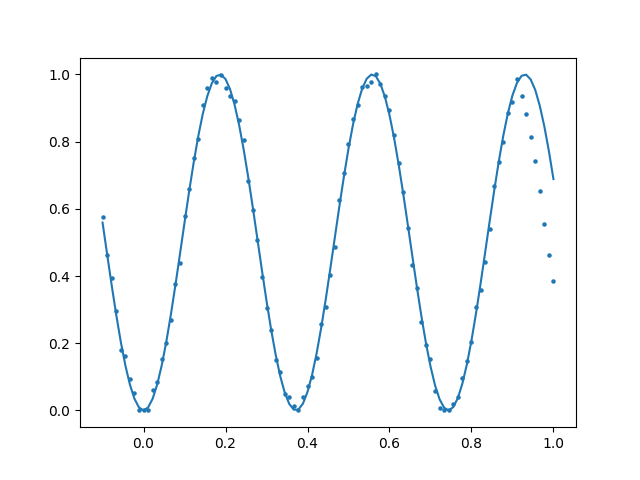

In [7]:
fig, ax = plt.subplots()

ax.plot(rabi01_data['amp_sweep'], population1_rabi01_sim)
ax.scatter(rabi01_data['amp_sweep'], rabi01_data['population_1'], s=5)

## Rabi 12

In [8]:
# before correction
rabi12_data = np.load('./data/rabi_osc/rabi12before_active_reset_brisbane109.npz', allow_pickle=True)

rabi12_data

NpzFile './data/rabi_osc/rabi12before_active_reset_brisbane109.npz' with keys: amp_sweep, population_2

In [9]:
# for consistency at this stage we ignore the couplings between different subspaces

population2_rabi12_sim = sim_rabi_osc(gate_model='pi_pulse', subspace='12', lambda_0=0.526, lambda_1=0.591, lambda_2=0, amp_sweep=rabi12_data['amp_sweep'])

-1.9295662078348508 20


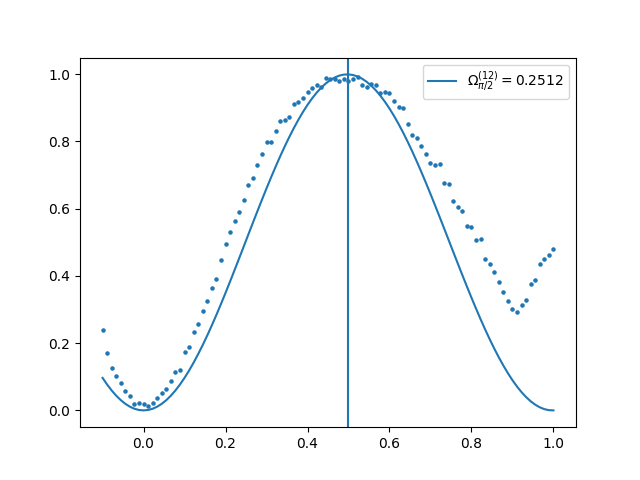

In [10]:
fig, ax = plt.subplots()

ax.plot(rabi12_data['amp_sweep'], population2_rabi12_sim)
ax.scatter(rabi12_data['amp_sweep'], rabi12_data['population_2'], s=5)
amp_pi_over_two_12_old = 0.2512
ax.axvline(rabi12_data['amp_sweep'][np.argmax(population2_rabi12_sim)], label=r'$\Omega_{\pi/2}^{(12)}=$'+f'{amp_pi_over_two_12_old}')
ax.legend()

In [11]:
# after correction
rabi12_data = np.load('./data/rabi_osc/rabi12after_amps_-0.05_0.3_brisbane109.npz', allow_pickle=True)

rabi12_data

NpzFile './data/rabi_osc/rabi12after_amps_-0.05_0.3_brisbane109.npz' with keys: amp_sweep, iq_data, pop2

In [12]:
population2_rabi12_sim = sim_rabi_osc(gate_model='pi_over_two_pulse', subspace='12', lambda_0=0.526, lambda_1=0.621, lambda_2=0, amp_sweep=rabi12_data['amp_sweep'])

# We ended up taking 0.621 (after correction) to be the relative driving strength of subspace 12 in our simulation, not 0.592 (before correction)

-1.9295662078348508 20


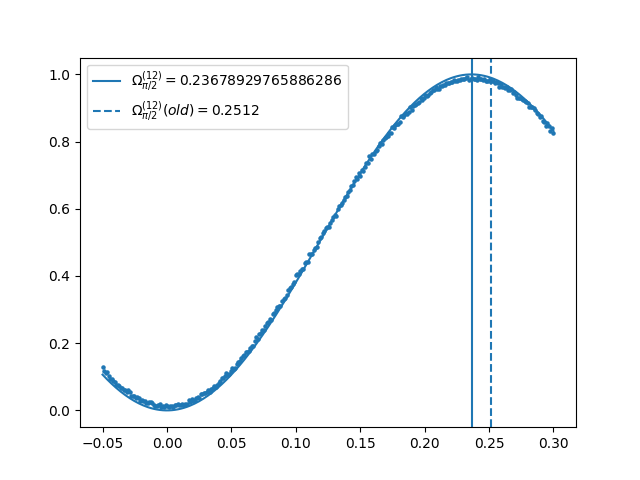

In [13]:
fig, ax = plt.subplots()

ax.plot(rabi12_data['amp_sweep'], population2_rabi12_sim)
ax.scatter(rabi12_data['amp_sweep'], rabi12_data['pop2'], s=5)
amp_pi_over_two_12 = rabi12_data['amp_sweep'][np.argmax(population2_rabi12_sim)]
ax.axvline(rabi12_data['amp_sweep'][np.argmax(population2_rabi12_sim)], label=r'$\Omega_{\pi/2}^{(12)}=$'+f'{amp_pi_over_two_12}')
ax.axvline(amp_pi_over_two_12_old, label=r'$\Omega_{\pi/2}^{(12)} (old)=$'+f'{amp_pi_over_two_12_old}', linestyle='--')
ax.legend()

In [14]:
amp_pi_over_two_12

np.float64(0.23678929765886286)

## Rabi 23

Because the conditional dispersive shift of the qudit state $|3\rangle$ is too small, the state $|3\rangle$ is readout as follow: preparing state $|2\rangle$, then do Rabi oscillations with different drive amplitude $\Omega^{(23)}$, following by two population swaps $\pi_{12}$ and $\pi_{01}$. The readout population is then oscillations between $|0\rangle$ and $|3\rangle$. This procedure is similar to that of Peterer 2010 (https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.114.010501).

In [360]:
rabi23_data = np.load('./data/rabi_osc/rabi23_active_reset_pi12_pi01_brisbane109.npz', allow_pickle=True)

rabi23_data

NpzFile './data/rabi_osc/rabi23_active_reset_pi12_pi01_brisbane109.npz' with keys: amp_sweep, population_3

In [361]:
population3_rabi23_sim = sim_rabi_osc(gate_model='pi_pulse', subspace='23', lambda_0=0.526, lambda_1=0.621, lambda_2=0.753, amp_sweep=rabi23_data['amp_sweep'])

-3.8591324156697016 60


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


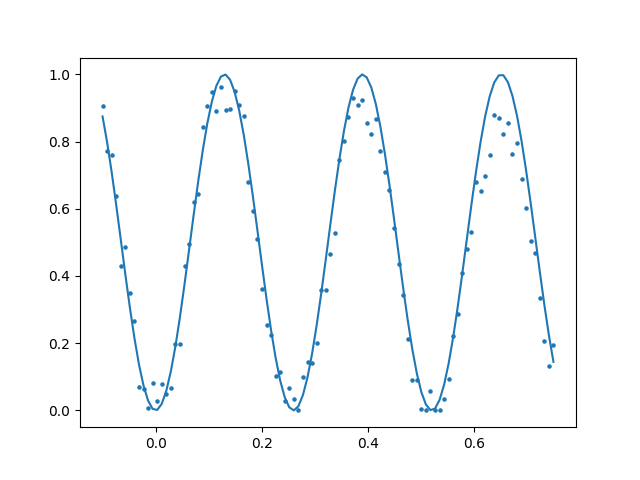

In [365]:
fig, ax = plt.subplots()

ax.plot(rabi23_data['amp_sweep'], population3_rabi23_sim)
ax.scatter(rabi23_data['amp_sweep'], rabi23_data['population_3'], s=5)

In [363]:
lambdas = np.array([0.526, 0.621, 0.753])

In [364]:
np.savez('./data/rabi_osc/lambda_values.npz', lambdas=lambdas)